# Probiotic field trial data

In [15]:
#load libraries
library(ggplot2)
library(tidyverse)
library(vegan)
library(RColorBrewer)
library(dplyr)

### looking at disease frequency over time in probiotic treated Orbicella's  

3 sites: Rocosa, Plazadetoros, and El Arbol

calculated disease frequency over time for each group and put in a table

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/probiotic_trials")

In [7]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/probiotic_trials"

In [19]:
d_table <- read.table("disease_freq_081926_t.csv", header=TRUE, sep=",")

read.csv didn't work, so I reopened in BBedit and entered the last line. Then used read.table with a sep flag

In [20]:
d_table

day,disease_control,disease_treatment,healthy_control
<int>,<dbl>,<dbl>,<dbl>
1,100.0,100.0,0.00
5,100.0,100.0,6.67
42,78.9,28.9,0.00
84,72.7,50.0,0.00


In [22]:
#pivot longer
pivot_table <- d_table %>%
    pivot_longer(-c(day), names_to = "group", values_to = c("disease_freq"))
head(pivot_table)

day,group,disease_freq
<int>,<chr>,<dbl>
1,disease_control,100.00
1,disease_treatment,100.00
1,healthy_control,0.00
5,disease_control,100.00
5,disease_treatment,100.00
5,healthy_control,6.67


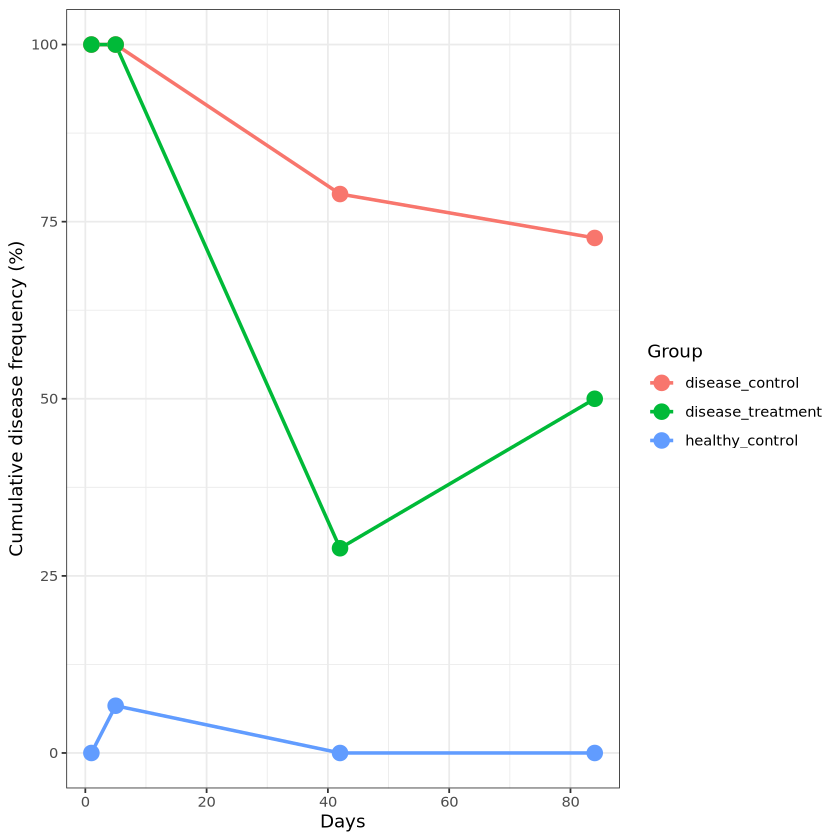

In [25]:
plot1 <- ggplot(pivot_table, aes(x = day, y = disease_freq, color=group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4)+
  theme_bw() +
  labs(x = "Days", y = "Cumulative disease frequency (%)", color= "Group")
plot1

In [26]:
options(repr.plot.width=8, repr.plot.height=8)

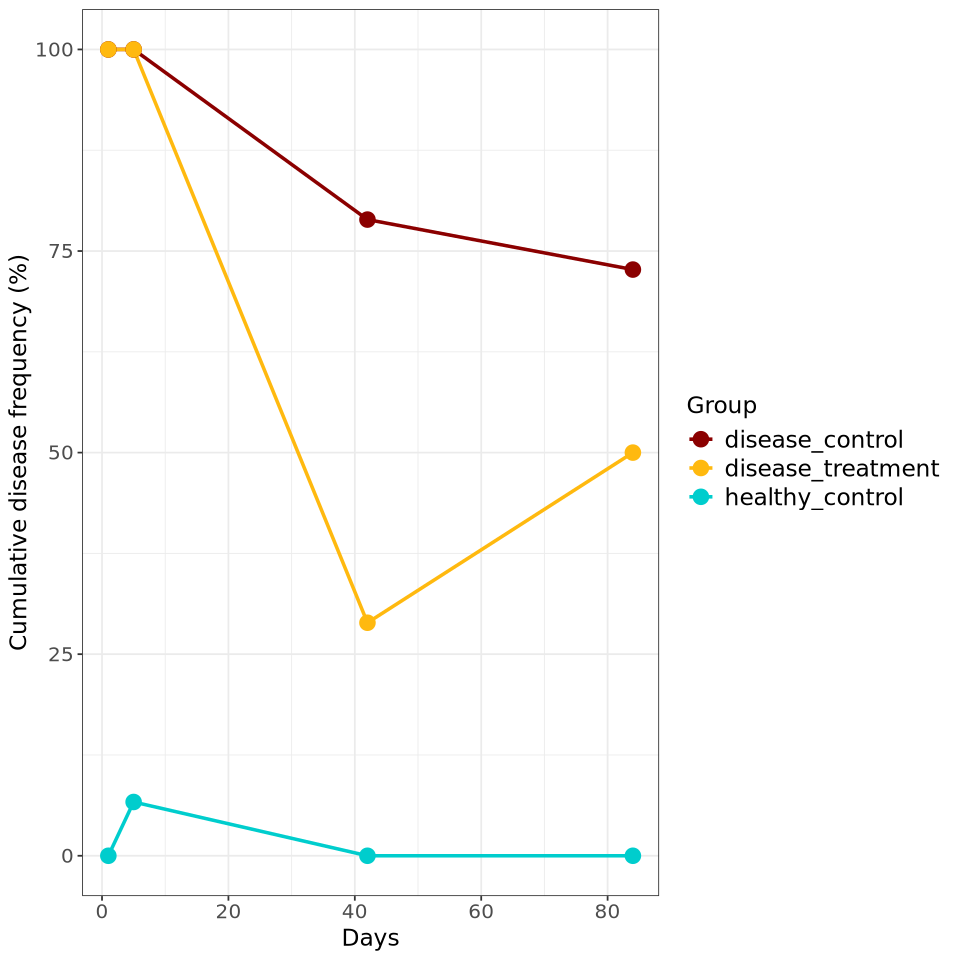

In [35]:
plot2 <- ggplot(pivot_table, aes(x = day, y = disease_freq, color=group)) +
  geom_line(linewidth = 1) +
  geom_point(size = 4)+
 scale_color_manual(values=c("darkred","darkgoldenrod1","cyan3"))+
  theme_bw() +
theme(axis.text.y = element_text(size = 12),
      axis.text.x = element_text(size = 12),
      axis.title.x = element_text(size = 14),
      axis.title.y = element_text(size = 14),
     legend.text = element_text(size = 14),
     legend.title = element_text(size = 14))+
  labs(x = "Days", y = "Cumulative disease frequency (%)", color= "Group")
plot2

In [36]:
ggsave(filename = "Trials_disease_freq.png", plot = plot2, 
      width = 8,
      height = 8,
      units = "in",
      dpi = 300)

**included all disease and didn't distinguish between those with new lesions, also a few "healthy" had disease progression measurements so should check in about that**